## ``ML-Regression Model - NVIDIA``

##### ``Sandra Ranilla-Cortina``

In [17]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('fivethirtyeight')
np.random.seed(777)

import warnings
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = FutureWarning)

#### ``Exploratory Data Analysis (EDA)``

In [2]:
# NVIDIA Stock Price 5Y dataset
df_nvidia = pd.read_csv('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-DL/data/NVIDIA/NVIDIAStockPrice5Y-Dataset.csv', usecols = lambda column: column != 'Unnamed: 0')
df_nvidia['date'] = pd.to_datetime(df_nvidia['date'])
df_nvidia = df_nvidia.sort_values('date')
df_nvidia.head(5)

,date,open,high,low,close,volume,Name
0,2013-02-08,12.370,12.4699,12.29,12.37,7677336,NVDA
1,2013-02-11,12.470,12.6350,12.35,12.51,10207599,NVDA
2,2013-02-12,12.395,12.5650,12.38,12.43,6945065,NVDA
3,2013-02-13,12.440,12.6650,12.33,12.37,21322573,NVDA
4,2013-02-14,12.200,12.7400,12.05,12.73,22049335,NVDA


In [3]:
# Daily return (yield) and trading volume return
df_nvidia['yield'] = df_nvidia['close'].pct_change()
df_nvidia['trading_volume_return'] = df_nvidia['volume'].pct_change()
df_nvidia.dropna(inplace = True) # drop first line

In [4]:
# Features type
df_nvidia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1258 entries, 1 to 1258
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1258 non-null   datetime64[ns]
 1   open                   1258 non-null   float64       
 2   high                   1258 non-null   float64       
 3   low                    1258 non-null   float64       
 4   close                  1258 non-null   float64       
 5   volume                 1258 non-null   int64         
 6   Name                   1258 non-null   object        
 7   yield                  1258 non-null   float64       
 8   trading_volume_return  1258 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 98.3+ KB


In [5]:
# Features description
df_nvidia[['open', 'high', 'low', 'close', 'volume', 'yield', 'trading_volume_return']].describe()

,open,high,low,close,volume,yield,trading_volume_return
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000
mean,56.351479,57.106773,55.547462,56.404344,1.046802e+07,0.002563,0.083750
std,59.600953,60.428109,58.648437,59.635432,7.205539e+06,0.022350,0.477835
min,12.070000,12.290000,12.040000,12.126000,1.141128e+06,-0.092723,-0.759334
25%,18.345000,18.580000,18.180075,18.365000,6.162788e+06,-0.007525,-0.220822
50%,22.635000,22.840000,22.377500,22.675000,8.419236e+06,0.001673,-0.030458
75%,71.382500,72.027500,70.418750,71.160000,1.202712e+07,0.011983,0.251142
max,245.770000,249.270000,244.450000,246.850000,9.232320e+07,0.298067,3.196751


#### ``Visualization``

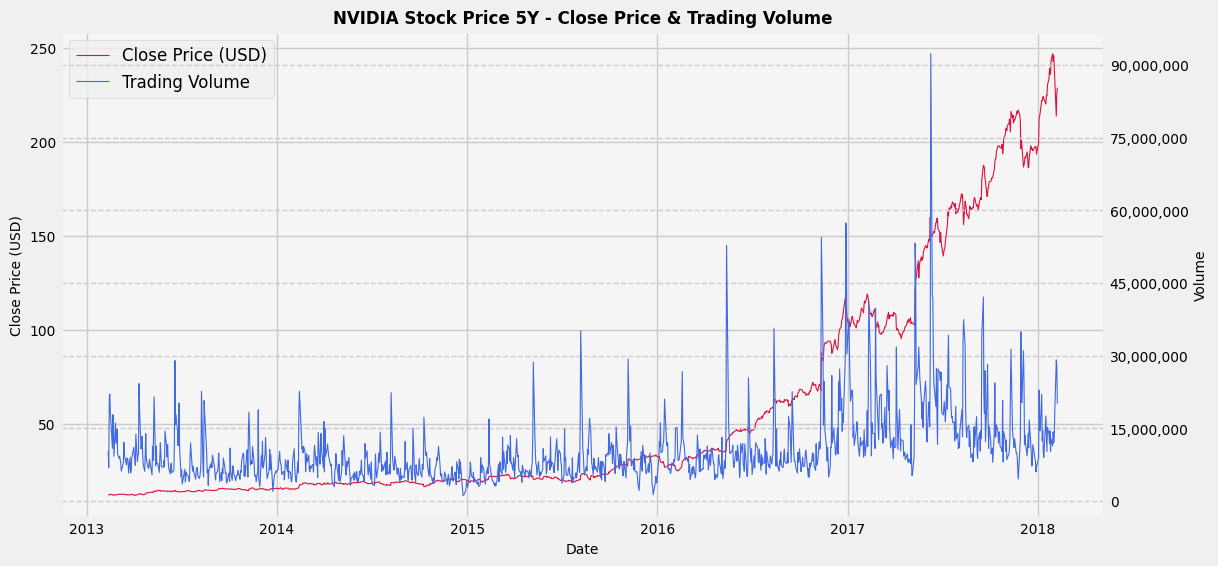

In [6]:
# Visualization - NVIDIA Stock Price 5Y (Close Price & Trading Volume)
fig = plt.figure(figsize = (12, 6))
ax1 = fig.gca()
ax1.set_facecolor('whitesmoke')
line1, = ax1.plot(df_nvidia['date'], df_nvidia['close'], label = 'Close Price', color = 'crimson', linewidth = 0.8)
ax1.set_ylabel('Close Price (USD)', fontsize = 10)
ax1.tick_params(axis = 'y', labelsize = 10)
ax2 = ax1.twinx()
line2, = ax2.plot(df_nvidia['date'], df_nvidia['volume'], label = 'Trading Volume', color = 'royalblue', linewidth = 0.8)
ax2.set_ylabel('Volume', fontsize = 10)
ax2.tick_params(axis = 'y', labelsize = 10)
ax2.yaxis.set_major_locator(MaxNLocator(integer = True))
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.grid(linestyle = '--')
plt.title('NVIDIA Stock Price 5Y - Close Price & Trading Volume', fontsize = 12, fontweight = 'bold')
ax1.set_xlabel('Date', fontsize = 10)
ax1.tick_params(axis = 'x', labelsize = 10)
handles = [line1, line2]
labels = ['Close Price (USD)', 'Trading Volume']
legend = ax1.legend(handles = handles, labels = labels, loc = 'upper left', frameon = True, prop = {'size': 12})
legend.get_frame().set_linewidth(0.5);

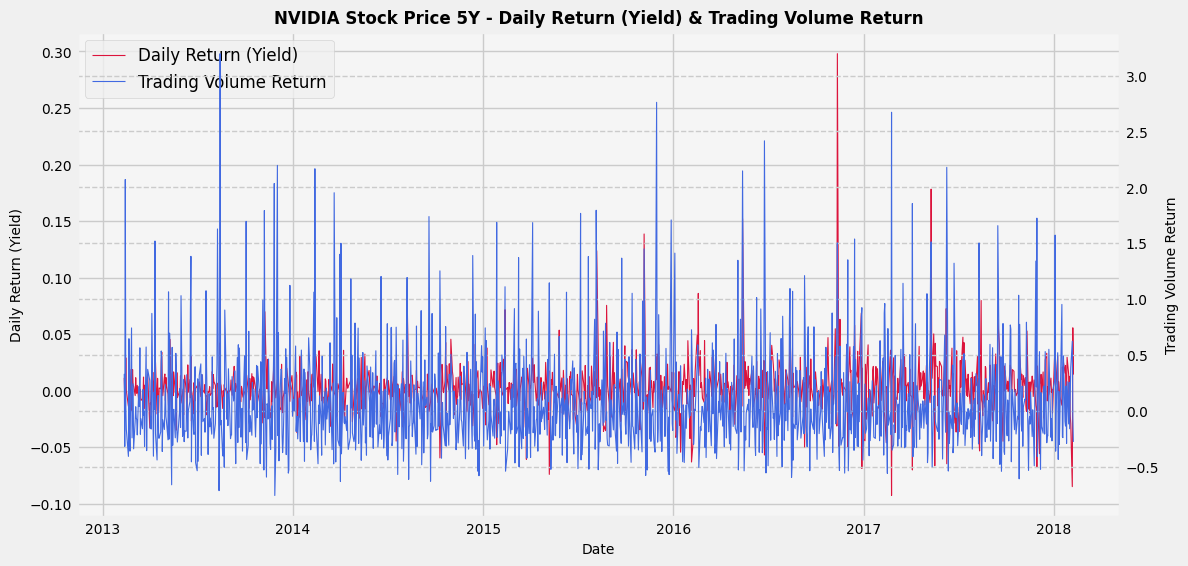

In [7]:
# Visualization - NVIDIA Stock Price 5Y (Daily Return-Yield & Trading Volume Return)
fig = plt.figure(figsize = (12, 6))
ax1 = fig.gca()
ax1.set_facecolor('whitesmoke')
line1, = ax1.plot(df_nvidia['date'], df_nvidia['yield'], label = 'Daily Return (Yield)', color = 'crimson', linewidth = 0.8)
ax1.set_ylabel('Daily Return (Yield)', fontsize = 10)
ax1.tick_params(axis = 'y', labelsize = 10)
ax2 = ax1.twinx()
line2, = ax2.plot(df_nvidia['date'], df_nvidia['trading_volume_return'], label = 'Trading Volume Return', color = 'royalblue', linewidth = 0.8)
ax2.set_ylabel('Trading Volume Return', fontsize = 10)
ax2.tick_params(axis = 'y', labelsize = 10)
plt.grid(linestyle = '--')
plt.title('NVIDIA Stock Price 5Y - Daily Return (Yield) & Trading Volume Return', fontsize = 12, fontweight = 'bold')
ax1.set_xlabel('Date', fontsize = 10)
ax1.tick_params(axis = 'x', labelsize = 10)
handles = [line1, line2]
labels = ['Daily Return (Yield)', 'Trading Volume Return']
legend = ax1.legend(handles = handles, labels = labels, loc = 'upper left', frameon = True, prop = {'size': 12})
legend.get_frame().set_linewidth(0.5);


#### ``Data Pre-Processing``

In [8]:
# NA-values
for col in df_nvidia.columns.tolist():          
    print('{} column missing values: {}'.format(col, df_nvidia[col].isnull().sum()))

date column missing values: 0
open column missing values: 0
high column missing values: 0
low column missing values: 0
close column missing values: 0
volume column missing values: 0
Name column missing values: 0
yield column missing values: 0
trading_volume_return column missing values: 0


In [9]:
# Create new features
df_nvidia['day'] = df_nvidia['date'].dt.day
df_nvidia['month'] = df_nvidia['date'].dt.month
df_nvidia['year'] = df_nvidia['date'].dt.year
print(df_nvidia.shape)

(1258, 12)


In [12]:
# Feature Selection + Target
X = df_nvidia.drop(['date', 'yield', 'trading_volume_return', 'close', 'Name'], axis = 1)
Y = df_nvidia['close']
print(X.shape)
print(Y.shape)

(1258, 7)
(1258,)


In [13]:
# Numerical features
sc = StandardScaler()

numerical_variables = ['open', 'high', 'low', 'volume']
for col in numerical_variables:
    X[[col]] = sc.fit_transform(X[[col]])
X.head()

,open,high,low,volume,day,month,year
1,-0.736547,-0.736238,-0.736842,-0.036156,11,2,2013
2,-0.737806,-0.737397,-0.736330,-0.489117,12,2,2013
3,-0.737051,-0.735741,-0.737183,1.507017,13,2,2013
4,-0.741079,-0.734500,-0.741959,1.607919,14,2,2013
5,-0.732687,-0.733672,-0.735136,1.093822,15,2,2013


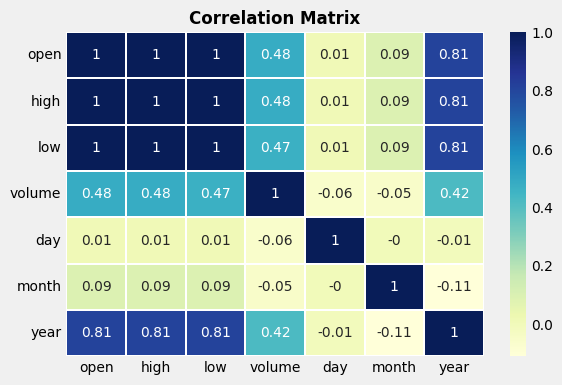

In [14]:
# Correlation Matrix
mcorr = X.corr().round(2)
fig = plt.figure(figsize = (6, 4))
sns.heatmap(mcorr, annot = True, linewidth = 0.2, cmap = 'YlGnBu', annot_kws = {'size': 10})
plt.title('Correlation Matrix', fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize = 10)

In [15]:
# Train-vs-Test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 1)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(943, 7)
(943,)
(315, 7)
(315,)


#### ``Modelling``

In [ ]:
# 1. K-Nearest Neighbors (KNN) model

# Model
model_knn = KNeighborsRegressor(n_neighbors = 5)

# Training
model_knn.fit(X_train, Y_train)

# Predict
y_pred_knn = model_knn.predict(X_test)

# Evaluation
mae_knn = mean_absolute_error(Y_test, y_pred_knn)
mse_knn = mean_squared_error(Y_test, y_pred_knn)
print(f'K-Nearest Neighbors (KNN) model \n -> MAE = {mae_knn:.4f} \n -> MSE = {mse_knn:.4f}')

K-Nearest Neighbors (KNN) 
 -> MAE = 4.6891 
 -> MSE = 63.6058


In [ ]:
# 2. Decision Tree Regressor (DT) model

# Model
model_dt = DecisionTreeRegressor(random_state = 42)

# Training
model_dt.fit(X_train, Y_train)

# Predict
y_pred_dt = model_dt.predict(X_test)

# Evaluation
mae_dt = mean_absolute_error(Y_test, y_pred_dt)
mse_dt = mean_squared_error(Y_test, y_pred_dt)
print(f'Decision Tree Regressor (DT) model \n -> MAE = {mse_dt:.4f} \n -> MSE = {mse_dt:.4f}')

Decision Tree Regressor (DT) 
 -> MAE = 1.4985 
 -> MSE = 1.4985


In [ ]:
# 3. Support Vector Regressor (SVR) model

# Model
model_svr = SVR(kernel = 'rbf', C = 1e3, gamma = 0.1)

# Training
model_svr.fit(X_train, Y_train)

# Predict
y_pred_svr = model_svr.predict(X_test)

# Evaluation
mae_svr = mean_absolute_error(Y_test, y_pred_svr)
mse_svr = mean_squared_error(Y_test, y_pred_svr)
print(f'Support Vector Regressor (SVR) model \n -> MAE = {mae_svr:.4f} \n -> MSE = {mse_svr:.4f}')

Support Vector Regressor (SVR) 
 -> MAE = 1.6133 
 -> MSE = 12.9715


In [28]:
# 4. Linear Regression (LR) model

# Model
model_lr = LinearRegression()

# Training
model_lr.fit(X_train, Y_train)

# Predict
y_pred_lr = model_lr.predict(X_test)

# Evaluation
mae_lr = mean_absolute_error(Y_test, y_pred_lr)
mse_lr = mean_squared_error(Y_test, y_pred_lr)
print(f'Linear Regression (LR) model \n -> MAE = {mae_lr:.4f} \n -> MSE = {mse_lr:.4f}')

Linear Regression (LR) model 
 -> MAE = 0.3403 
 -> MSE = 0.4164


In [29]:
# 5. Random Forest Regressor (RF) model

# Model
model_rf = RandomForestRegressor(n_estimators = 100, random_state = 42)

# Training
model_rf.fit(X_train, Y_train)

# Predict
y_pred_dt = model_rf.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(Y_test, y_pred_dt)
mse_rf = mean_squared_error(Y_test, y_pred_dt)
print(f'Random Forest Regressor (RF) model \n -> MAE = {mae_rf:.4f} \n -> MSE = {mse_rf:.4f}')

Random Forest Regressor (RF) model 
 -> MAE = 0.5437 
 -> MSE = 1.1225


Which is the **``best performing model``**?  

- **Linear Regression (LR) model**: achieved the lowest Mean Absolute Error ($MAE = 0.3403$) and Mean Squared Error ($MSE = 0.4164$). Its strong performance suggests a largely linear relationship in the data. Simple, interpretable, and highly generalizable.

- **Random Forest Regressor (RF) model**: performed well with $MAE = 0.5437$ and $MSE = 1.1225$, capturing non-linearities effectively. However, its added complexity did not surpass the performance of LR, possibly leading to slight overfitting.

- **Decision Tree Regressor (DT) model**: produced $MAE = 1.4985$ and $MSE = 1.4985$. Tends to overfit and offer limited precision, especially with sequential or unscaled data.

- **Support Vector Regressor (SVR) model**: results were less favorable ($MAE = 1.6133$, $MSE = 12.9715$). Sensitive to hyperparameters and potentially affected by suboptimal scaling or noise.

- **K-Nearest Neighbors (KNN) model**: showed the weakest performance ($MAE = 4.6891$, $MSE = 63.6058$). Struggles with evolving patterns in time-series-like data and lacks generalization.

The **``Linear Regression model``** stands out as the **best choice** due to its minimal error, simplicity, and effectiveness. Its strong performance confirms the presence of a mostly linear pattern in the data, making it preferable over more complex alternatives for this regression task.